In [7]:
%pip install --no-deps -e /mnt/c/Github/sealwatch --force-reinstall
# %pip install opencv-python numpy scipy jpeglib h5py pandas pillow timm tqdm
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Obtaining file:///mnt/c/Github/sealwatch
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sealwatch (pyproject.toml) ... done
  Created wheel for sealwatch: filename=sealwatch-2025.9-cp38-abi3-linux_x86_64.whl size=14760 sha256=4025f984d4e5b2b92bb913fb0dc63745260d65e5dd411ea392635edf70614107
  Stored in directory: /tmp/pip-ephem-wheel-cache-0689ngl4/wheels/09/64/7a/ddca0d00d3d96e147011b583fa244989ab4f61075225ce6855
Successfully built sealwatch
  Attempting uninstall: sealwatch
    Found existing installation: sealwatch 2025.9
    Uninstalling sealwatch-2025.9:
      Successfully uninstalled sealwatch-2025.9
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import os


def load_img(name, perc, method):
    if method == "cover":
        base_path = Path("/home/feierabe/info_hiding_data/boss_cover")
    else:
        base_path = (
            Path("/home/feierabe/info_hiding_data/stegos/data/jpeg")
            / method
            / str(round(perc * 100))
        )
    img_path = base_path / f"{name}.png"
    with Image.open(img_path) as img:
        return np.array(img.convert("L"))

In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import jpeglib
import os
from tqdm import tqdm
from sealwatch.cost_estimator import attack_jpeg

data_dir = Path("/home/feierabe/info_hiding_data/stegos/data/jpeg")

skip_methods = ["cover"]
methods = [
    d.name
    for d in data_dir.iterdir()
    if d.is_dir() and d.name not in skip_methods
]

skip_alphas = [
    "10",
    "15",
    "20",
    "25",
    "45",
]  # ["10", "15", "25", "35", "45", "90", "100"]
limit_images = 5

csv_path = "results_jpeg.csv"
df = pd.DataFrame()


def load_jpeg(image_id, alpha_dir_name, method):
    alpha_pct = int(float(alpha_dir_name) * 100)
    if method == "cover":
        path = data_dir / "cover" / f"{image_id}.jpg"
    else:
        path = data_dir / method / alpha_dir_name / f"{image_id}.jpg"

    dct_j = jpeglib.read_dct(str(path))
    spatial_j = jpeglib.read_spatial(str(path))
    return dct_j.Y, spatial_j.spatial[:, :, 0], dct_j.qt[0]


rows = []
for method in methods:
    print("method: ", method)
    method_dir = (
        Path("/home/feierabe/info_hiding_data/stegos/data/jpeg") / method
    )
    alpha_dirs = [
        d
        for d in method_dir.iterdir()
        if d.is_dir() and d.name not in skip_alphas
    ]
    for alpha_dir in tqdm(alpha_dirs, desc=method, unit="alpha"):
        print(alpha_dir)
        # print("Method: ", method, " alpha: ", alpha_dir)
        if not alpha_dir.is_dir():
            continue
        if alpha_dir.name in skip_alphas:
            continue
        alpha = int(alpha_dir.name) / 100

        image_ids = [f.stem for f in alpha_dir.glob("*.jpg")]
        found = []
        for image_id in image_ids[:limit_images]:
            cover_dct, cover_spatial, qtable = load_jpeg(
                image_id, alpha_dir.name, "cover"
            )
            stego_dct, _, _ = load_jpeg(image_id, alpha_dir.name, method)

            result = attack_jpeg(stego_dct, cover_dct, cover_spatial, qtable)

            delta = (
                stego_dct.astype(np.int32) - cover_dct.astype(np.int32)
            ).astype(np.float64)

            pred_method = result["method"]
            pred_M = result["M"]
            all_results = result["all"]
            found.append(pred_method)

            n_nzAC = int((cover_dct != 0).sum()) - int(
                (cover_dct[:, :, 0, 0] != 0).sum()
            )

            # for r in sorted(result['all'], key=lambda x: x['log_lik'], reverse=True):
            #    print(f"  {r['method_name']:10s}  log_lik={r['log_lik']:.1f}")
            rows.append(
                {
                    "image_id": image_id,
                    "alpha": alpha,
                    "true_method": method,
                    "pred_method": pred_method,
                    "pred_M": pred_M,
                    "n_nzAC": n_nzAC,
                }
            )
        # print("methods: ", found)
df = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)
df.to_csv(csv_path, index=False)
print(f"Saved to {csv_path}")

/home/feierabe/venv_info_projekt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


method:  uerd


uerd:   0%|                                                                          | 0/9 [00:00<?, ?alpha/s]

/home/feierabe/info_hiding_data/stegos/data/jpeg/uerd/80


/home/feierabe/venv_info_projekt/lib/python3.12/site-packages/conseal/ebs/_costmap.py:78: RuntimeWarning: divide by zero encountered in divide
  block_distortion = 1/(block_entropies**theta)
uerd:  11%|███████▎                                                          | 1/9 [00:01<00:08,  1.06s/alpha]

...

/home/feierabe/info_hiding_data/stegos/data/jpeg/nsf5/30


nsf5:  89%|██████████████████████████████████████████████████████████▋       | 8/9 [00:08<00:01,  1.10s/alpha]

/home/feierabe/info_hiding_data/stegos/data/jpeg/nsf5/70


nsf5: 100%|██████████████████████████████████████████████████████████████████| 9/9 [00:09<00:00,  1.08s/alpha]

Saved to results_jpeg.csv


Loaded: 2520 rows
Overall accuracy: 82.54%


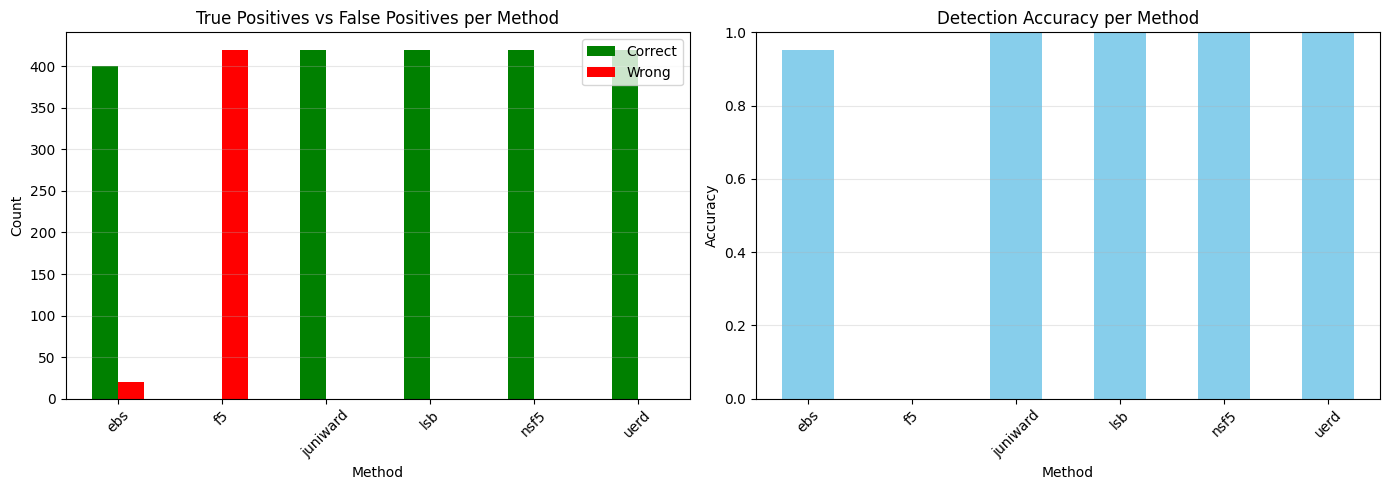

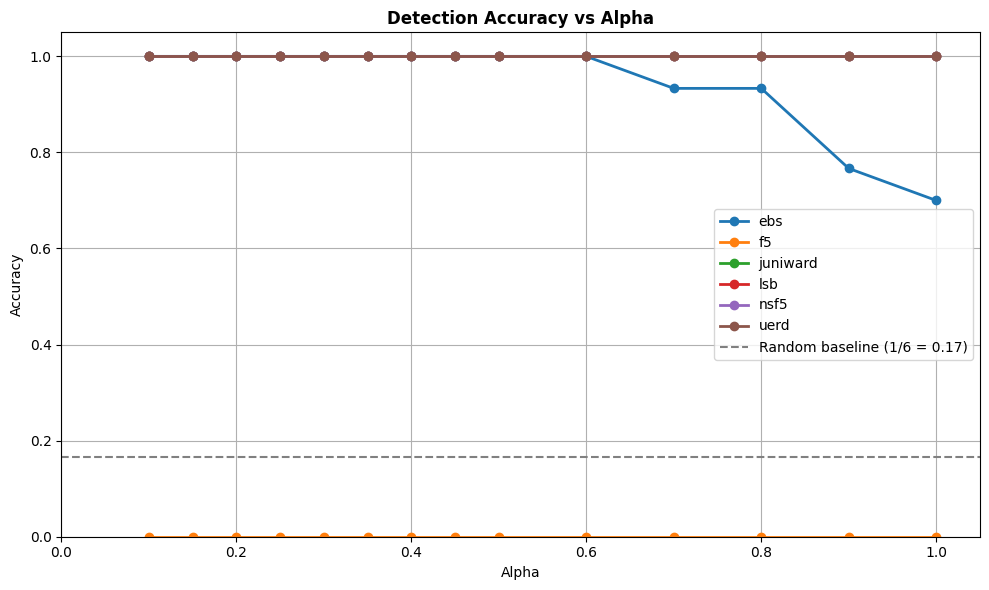

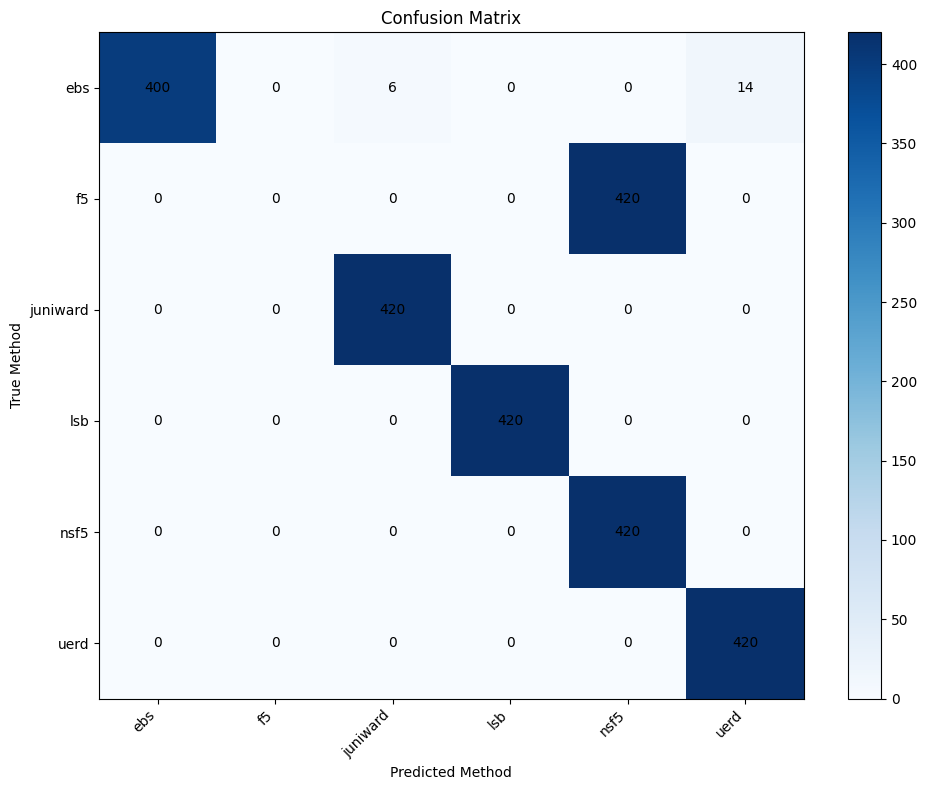


Summary:
              TP  Total  Accuracy   FP
true_method                           
ebs          400    420  0.952381   20
f5             0    420  0.000000  420
juniward     420    420  1.000000    0
lsb          420    420  1.000000    0
nsf5         420    420  1.000000    0
uerd         420    420  1.000000    0

Confusion Matrix:
pred_method  ebs  f5  juniward  lsb  nsf5  uerd
true_method                                    
ebs          400   0         6    0     0    14
f5             0   0         0    0   420     0
juniward       0   0       420    0     0     0
lsb            0   0         0  420     0     0
nsf5           0   0         0    0   420     0
uerd           0   0         0    0     0   420
[np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

path = "./results_jpeg/test_friday_11/"
csv_file = path + "results_jpeg.csv"

if not Path(csv_file).exists():
    print(f"File not found: {csv_file}")
    exit()

df = pd.read_csv(csv_file)  # fehlte
df["alpha"] = pd.to_numeric(df["alpha"], errors="coerce")
df["correct"] = (df["pred_method"] == df["true_method"]).astype(int)

print(f"Loaded: {len(df)} rows")
print(f"Overall accuracy: {df['correct'].mean():.2%}")

# --- Plot 1: TP vs FP per method ---
accuracy = df.groupby("true_method")["correct"].agg(["sum", "count", "mean"])
accuracy.columns = ["TP", "Total", "Accuracy"]
accuracy["FP"] = accuracy["Total"] - accuracy["TP"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

accuracy[["TP", "FP"]].plot(kind="bar", ax=ax1, color=["green", "red"])
ax1.set_xlabel("Method")
ax1.set_ylabel("Count")
ax1.set_title("True Positives vs False Positives per Method")
ax1.legend(["Correct", "Wrong"])
ax1.grid(True, alpha=0.3, axis="y")
ax1.tick_params(axis="x", rotation=45)

accuracy["Accuracy"].plot(kind="bar", ax=ax2, color="skyblue")
ax2.set_xlabel("Method")
ax2.set_ylabel("Accuracy")
ax2.set_title("Detection Accuracy per Method")
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis="y")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(path + "results_tp_fp.png", dpi=300)
plt.show()

# --- Plot 2: Accuracy vs Alpha ---
fig, ax = plt.subplots(figsize=(10, 6))

for method in sorted(df["true_method"].unique()):
    method_data = df[df["true_method"] == method]
    acc_by_alpha = method_data.groupby("alpha")["correct"].mean()
    ax.plot(
        acc_by_alpha.index,
        acc_by_alpha.values,
        marker="o",
        label=method,
        linewidth=2,
    )

ax.set_xlabel("Alpha")
ax.set_ylabel("Accuracy")
ax.set_title("Detection Accuracy vs Alpha", fontweight="bold")
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(True)
ax.set_xlim(0, 1.05)

# Baseline
n_methods = df["true_method"].nunique()
random_accuracy = 1 / n_methods

# --- Plot 2: Accuracy vs Alpha --- (ergänzt)
ax.axhline(
    random_accuracy,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Random baseline (1/{n_methods} = {random_accuracy:.2f})",
)
ax.legend()

plt.tight_layout()
plt.savefig(path + "results_accuracy_vs_alpha.png", dpi=300)
plt.show()

# --- Plot 3: Confusion Matrix ---
cm = pd.crosstab(df["true_method"], df["pred_method"])

# ensure all methods appear on both axes
all_methods = sorted(set(df["true_method"]) | set(df["pred_method"]))
cm = cm.reindex(index=all_methods, columns=all_methods, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm.values, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(cm.columns)))
ax.set_yticks(range(len(cm.index)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticklabels(cm.index)
ax.set_xlabel("Predicted Method")
ax.set_ylabel("True Method")
ax.set_title("Confusion Matrix")

for i in range(len(cm.index)):
    for j in range(len(cm.columns)):
        ax.text(j, i, cm.values[i, j], ha="center", va="center", color="black")


plt.colorbar(im)
plt.tight_layout()
plt.savefig(path + "results_confusion_matrix.png", dpi=300)
plt.show()

print("\nSummary:")
print(accuracy)

print("\nConfusion Matrix:")
print(cm.to_string())

print(sorted(df["alpha"].unique()))

# --- Plot 4: M-Error vs Alpha ---
if "pred_M" in df.columns and "true_M" in df.columns:
    df["M_mse"] = (df["pred_M"] - df["true_M"]) ** 2
    fig, ax = plt.subplots(figsize=(10, 6))
    for method in sorted(df["true_method"].unique()):
        method_data = df[df["true_method"] == method]
        mse_by_alpha = method_data.groupby("alpha")["M_mse"].mean()
        ax.plot(
            mse_by_alpha.index,
            mse_by_alpha.values,
            marker="o",
            label=method,
            linewidth=2,
        )
    ax.axhline(
        1 / 6,
        color="gray",
        linestyle="--",
        linewidth=1.5,
        label="Random baseline (MSE=1/6)",
    )
    ax.set_xlabel("Alpha")
    ax.set_ylabel("MSE of M estimate")
    ax.set_title("M Estimation Error vs Alpha", fontweight="bold")
    ax.legend()
    ax.grid(True)
    ax.set_xlim(0, 1.05)
    plt.tight_layout()
    plt.savefig(path + "results_M_error.png", dpi=300)
    plt.show()

             M_error_abs  M_error_rel
true_method                          
ebs          8584.412314     1.864311
f5           2672.330476     0.494315
juniward     1443.627404     0.210396
lsb            65.027619     0.013730
nsf5         2930.892381     0.534344
uerd         1618.381200     0.232566


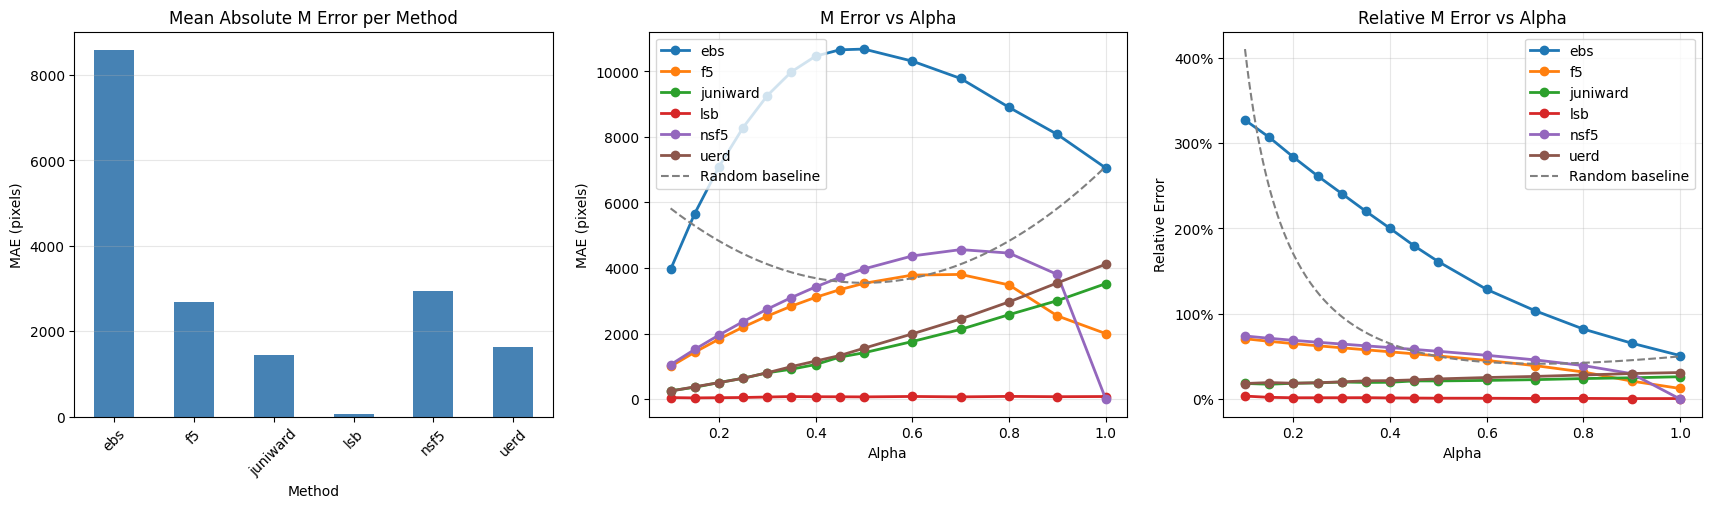

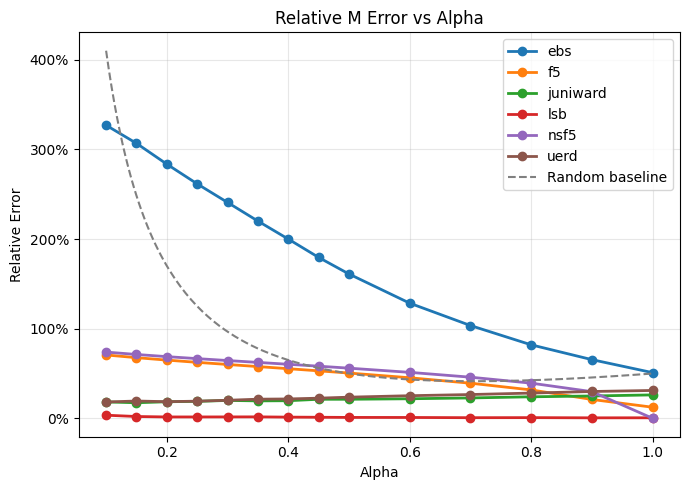

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

if not Path(csv_file).exists():
    print(f"File not found: {csv_file}")
    exit()

df = pd.read_csv(csv_file)
df["alpha"] = pd.to_numeric(df["alpha"], errors="coerce")

# true_M: alpha * image size (256x256)
df["true_M"] = df["alpha"] * df["n_nzAC"]
df["M_error"] = df["pred_M"] - df["true_M"]
df["M_error_abs"] = df["M_error"].abs()
df["M_error_rel"] = df["M_error_abs"] / df["true_M"]

print(df.groupby("true_method")[["M_error_abs", "M_error_rel"]].mean())

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Mean absolute M error per method
df.groupby("true_method")["M_error_abs"].mean().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Mean Absolute M Error per Method")
axes[0].set_xlabel("Method")
axes[0].set_ylabel("MAE (pixels)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3, axis="y")

# M error vs alpha per method
for method in sorted(df["true_method"].unique()):
    d = df[df["true_method"] == method].groupby("alpha")["M_error_abs"].mean()
    axes[1].plot(d.index, d.values, marker="o", label=method, linewidth=2)

axes[1].set_title("M Error vs Alpha")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("MAE (pixels)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Relative M error vs alpha per method
for method in sorted(df["true_method"].unique()):
    d = df[df["true_method"] == method].groupby("alpha")["M_error_rel"].mean()
    axes[2].plot(d.index, d.values, marker="o", label=method, linewidth=2)

axes[2].set_title("Relative M Error vs Alpha")
axes[2].set_xlabel("Alpha")
axes[2].set_ylabel("Relative Error")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[2].legend()
axes[2].grid(True, alpha=0.3)


# Baseline: random guesser draws alpha_hat ~ Uniform(0,1)
alpha_range = np.linspace(df["alpha"].min(), df["alpha"].max(), 200)
mean_n_nzAC = df["n_nzAC"].mean()

baseline_mae = (2 * alpha_range**2 - 2 * alpha_range + 1) / 2 * mean_n_nzAC
baseline_rel = (2 * alpha_range**2 - 2 * alpha_range + 1) / (2 * alpha_range)

axes[1].plot(
    alpha_range,
    baseline_mae,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Random baseline",
)
axes[2].plot(
    alpha_range,
    baseline_rel,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Random baseline",
)
axes[1].legend()
axes[2].legend()


# Relative M error vs alpha per method — extra Figure
fig2, ax = plt.subplots(figsize=(7, 5))
for method in sorted(df["true_method"].unique()):
    d = df[df["true_method"] == method].groupby("alpha")["M_error_rel"].mean()
    ax.plot(d.index, d.values, marker="o", label=method, linewidth=2)
ax.plot(
    alpha_range,
    baseline_rel,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Random baseline",
)
ax.set_title("Relative M Error vs Alpha")
ax.set_xlabel("Alpha")
ax.set_ylabel("Relative Error")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
ax.grid(True, alpha=0.3)
fig2.tight_layout()
fig2.savefig(path + "results_M_error_rel.png", dpi=300)


plt.tight_layout()
plt.savefig(path + "results_M_error.png", dpi=300)
plt.show()

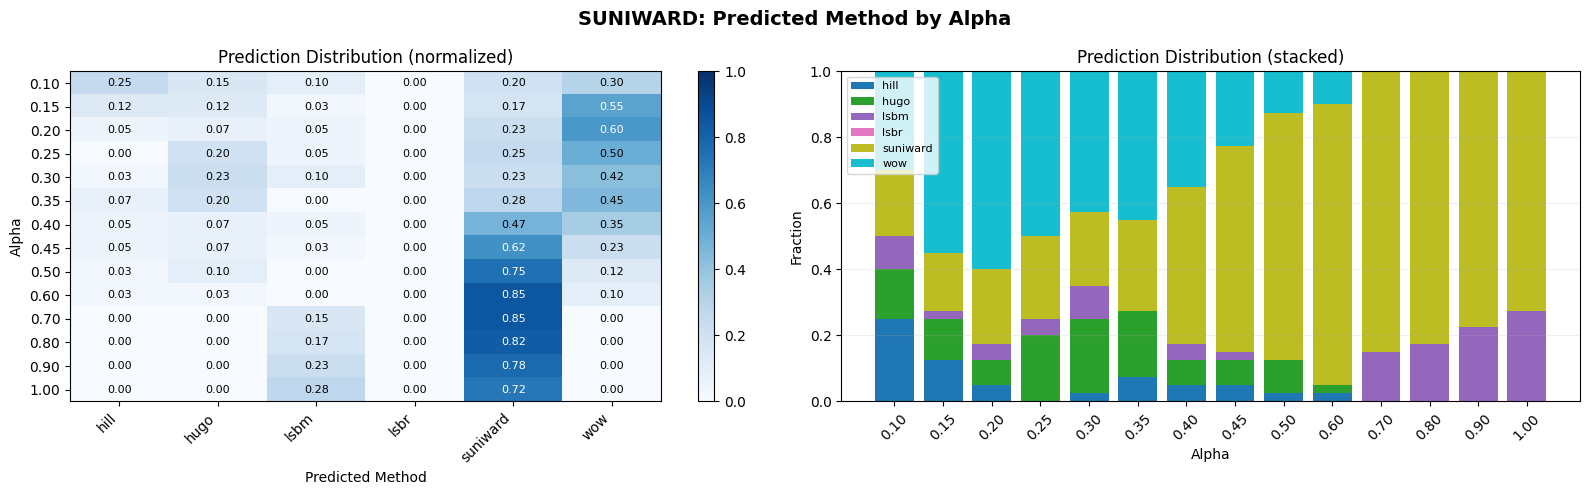

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

path = "./results/40images/"
csv_file = path + "results.csv"

df = pd.read_csv(csv_file)
df["alpha"] = pd.to_numeric(df["alpha"], errors="coerce")

# Only SUNIWARD rows
sun = df[df["true_method"] == "suniward"].copy()

alphas = sorted(sun["alpha"].unique())
all_methods = sorted(df["pred_method"].unique())

# Build matrix: rows = alpha, cols = predicted method
counts = pd.crosstab(sun["alpha"], sun["pred_method"])
counts = counts.reindex(columns=all_methods, fill_value=0)

# Normalize per alpha (row)
counts_norm = counts.div(counts.sum(axis=1), axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    "SUNIWARD: Predicted Method by Alpha", fontsize=14, fontweight="bold"
)

# --- Left: heatmap (normalized) ---
im = ax1.imshow(
    counts_norm.values, cmap="Blues", aspect="auto", vmin=0, vmax=1
)
ax1.set_xticks(range(len(counts_norm.columns)))
ax1.set_xticklabels(counts_norm.columns, rotation=45, ha="right")
ax1.set_yticks(range(len(counts_norm.index)))
ax1.set_yticklabels([f"{a:.2f}" for a in counts_norm.index])
ax1.set_xlabel("Predicted Method")
ax1.set_ylabel("Alpha")
ax1.set_title("Prediction Distribution (normalized)")

for i in range(len(counts_norm.index)):
    for j in range(len(counts_norm.columns)):
        val = counts_norm.values[i, j]
        ax1.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color="white" if val > 0.5 else "black",
            fontsize=8,
        )

plt.colorbar(im, ax=ax1)

# --- Right: stacked bar ---
bottom = np.zeros(len(alphas))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_methods)))

for j, method in enumerate(all_methods):
    vals = (
        counts_norm[method].values
        if method in counts_norm.columns
        else np.zeros(len(alphas))
    )
    ax2.bar(
        range(len(alphas)), vals, bottom=bottom, label=method, color=colors[j]
    )
    bottom += vals

ax2.set_xticks(range(len(alphas)))
ax2.set_xticklabels([f"{a:.2f}" for a in alphas], rotation=45)
ax2.set_xlabel("Alpha")
ax2.set_ylabel("Fraction")
ax2.set_title("Prediction Distribution (stacked)")
ax2.set_ylim(0, 1)
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig(path + "suniward_confusion_by_alpha.png", dpi=300)
plt.show()

In [10]:
import jpeglib
import numpy as np
from pathlib import Path
from sealwatch.cost_estimator import attack_jpeg
import conseal as cl

data_dir = Path("../data/jpeg")

image_id = "1"  # anpassen
method = "nsf5"
alpha_dir_name = "50"


def load_jpeg(image_id, alpha_dir_name, method):
    if method == "cover":
        path = data_dir / "cover" / f"{image_id}.jpg"
    else:
        path = data_dir / method / alpha_dir_name / f"{image_id}.jpg"
    dct_j = jpeglib.read_dct(str(path))
    spatial_j = jpeglib.read_spatial(str(path))
    return dct_j.Y, spatial_j.spatial[:, :, 0], dct_j.qt[0]


cover_dct, cover_spatial, qtable = load_jpeg(image_id, alpha_dir_name, "cover")
stego_dct, _, _ = load_jpeg(image_id, alpha_dir_name, method)


func = lambda: cl.nsF5.compute_cost_adjusted(y0=cover_dct)
func = lambda: cl.lsb.compute_cost_adjusted(cover=cover_dct)

rho_raw = np.asarray(func(), dtype=np.float64)
rho_mit_func = rho_raw[0] if rho_raw.ndim == 5 else rho_raw


rho = np.ones_like(cover_dct, dtype=np.float64)
rho[cover_dct == 0] = 1e13
rho[:, :, 0, 0] = 1e13